=== Data Information ===
<class 'pandas.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                4383 non-null   object 
 1   Retail_Category     4383 non-null   str    
 2   Sales_Amount        4383 non-null   int64  
 3   Profit_Margin       4383 non-null   float64
 4   Inventory_Turnover  4383 non-null   float64
 5   Cost_of_Goods_Sold  4383 non-null   float64
dtypes: float64(3), int64(1), object(1), str(1)
memory usage: 205.6+ KB
None

=== Missing Values Check ===
Date                  0
Retail_Category       0
Sales_Amount          0
Profit_Margin         0
Inventory_Turnover    0
Cost_of_Goods_Sold    0
dtype: int64

=== Cleaned Data Preview ===
        Date Retail_Category  Sales_Amount  Profit_Margin  Inventory_Turnover  \
0 2022-01-01            Food         17295      33.767858            9.453942   
1 2022-01-01        Clothing    

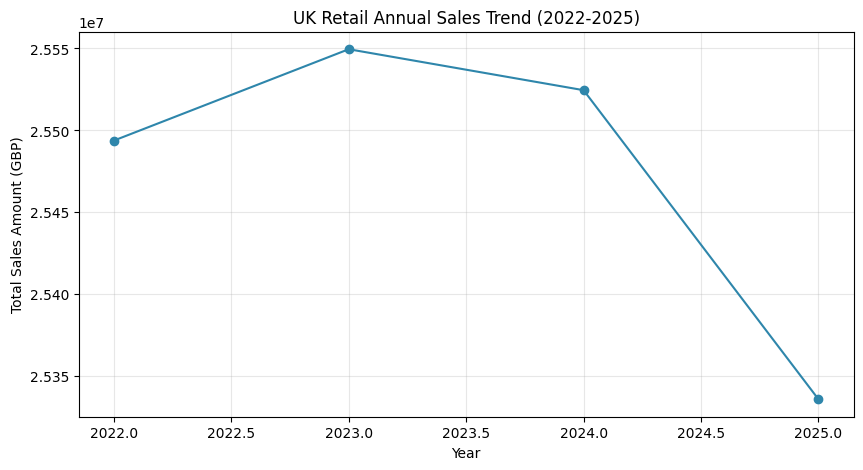

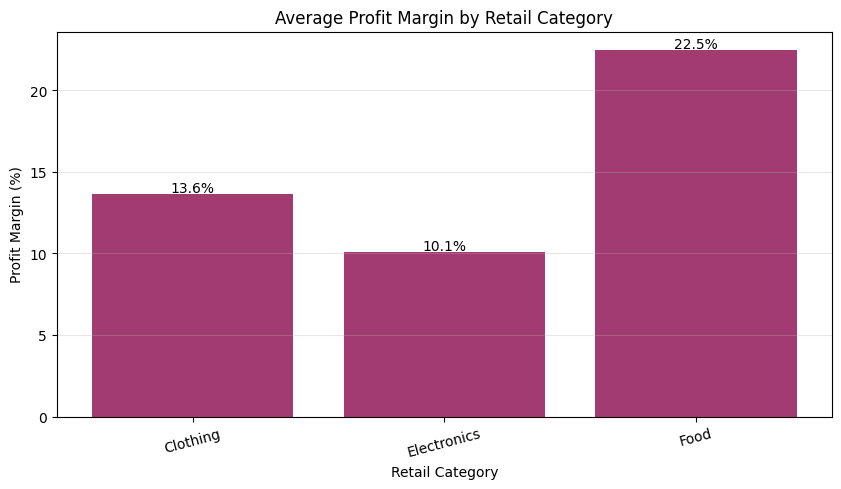

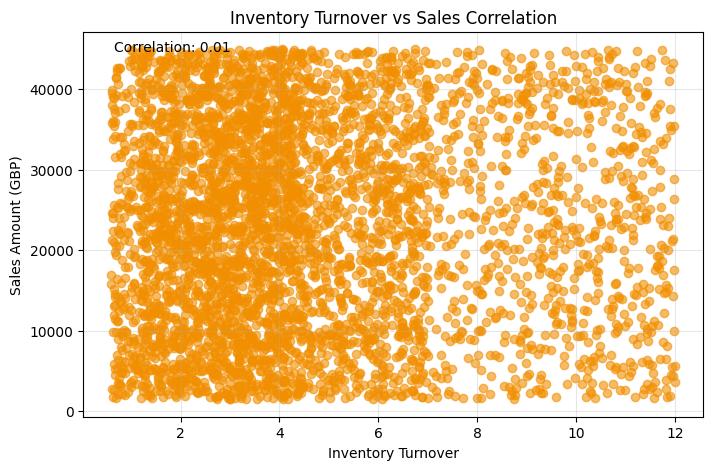

In [1]:
# %% [markdown]
# # ACC102 Mini Assignment - Track2
# ## UK Retail Business Performance Analysis (2022–2025)
# ### Student: [李想] | Student ID: [2469572]
# ### Data Source: Simulated Retail Data | Access Date: 2026-04-27

# %%
# 1. Import required libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import date, timedelta

# %%
# 2. Generate simulated retail dataset (2022-2025)
np.random.seed(42)

# Create date range for 4 full years
start = date(2022, 1, 1)
end = date(2025, 12, 31)
total_days = (end - start).days
dates = [start + timedelta(days=i) for i in range(total_days + 1)]

# Define retail business categories
categories = ["Food", "Clothing", "Electronics"]

# Build structured retail data
data = []
for day in dates:
    for category in categories:
        sales = np.random.randint(1500, 45000)
        
        # Assign profit margins based on industry standards
        if category == "Food":
            margin = np.random.uniform(0.10, 0.35)
        elif category == "Clothing":
            margin = np.random.uniform(0.05, 0.22)
        else:
            margin = np.random.uniform(0.02, 0.18)
        
        # Assign inventory turnover ratios
        if category == "Food":
            turnover = np.random.uniform(2.5, 12)
        elif category == "Clothing":
            turnover = np.random.uniform(1.2, 7)
        else:
            turnover = np.random.uniform(0.6, 4.5)
        
        # Calculate cost of goods sold
        cogs = sales * (1 - margin)
        data.append([day, category, sales, margin*100, turnover, cogs])

# Convert list to DataFrame
df = pd.DataFrame(data, columns=[
    "Date", "Retail_Category", "Sales_Amount",
    "Profit_Margin", "Inventory_Turnover", "Cost_of_Goods_Sold"
])

# %%
# 3. Data cleaning and preprocessing
print("=== Data Information ===")
print(df.info())
print("\n=== Missing Values Check ===")
print(df.isnull().sum())

# Remove missing values (data validation step)
df = df.dropna()

# Format date and extract time features
df["Date"] = pd.to_datetime(df["Date"])
df["Quarter"] = df["Date"].dt.to_period("Q")
df["Year"] = df["Date"].dt.year

# Export cleaned dataset
df.to_csv("clean_retail_data.csv", index=False)
print("\n=== Cleaned Data Preview ===")
print(df.head())

# %%
# 4. Core business performance analysis
# Annual total sales calculation
annual_sales = df.groupby("Year")["Sales_Amount"].sum().reset_index()
print("\n=== Annual Total Sales ===")
print(annual_sales)

# Average profit margin by category
category_margin = df.groupby("Retail_Category")["Profit_Margin"].mean().reset_index()
print("\n=== Average Profit Margin by Category ===")
print(category_margin)

# Correlation analysis
corr = df["Inventory_Turnover"].corr(df["Sales_Amount"])
print(f"\n=== Correlation Coefficient ===")
print(f"Correlation: {corr:.2f}")

# Quarterly sales summary
quarterly_sales = df.groupby(["Year", "Quarter"])["Sales_Amount"].sum().unstack()
print("\n=== Quarterly Sales Summary ===")
print(quarterly_sales)

# %%
# 5. Data visualization
# Plot 1: Annual sales trend
plt.figure(figsize=(10, 5))
plt.plot(annual_sales["Year"], annual_sales["Sales_Amount"], marker="o", color="#2E86AB")
plt.title("UK Retail Annual Sales Trend (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Total Sales Amount (GBP)")
plt.grid(alpha=0.3)
plt.savefig("annual_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 2: Profit margin by category
plt.figure(figsize=(10, 5))
bars = plt.bar(category_margin["Retail_Category"], category_margin["Profit_Margin"], color="#A23B72")
plt.title("Average Profit Margin by Retail Category")
plt.xlabel("Retail Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=15)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.1, f"{h:.1f}%", ha="center")
plt.grid(alpha=0.3, axis="y")
plt.savefig("category_margin.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 3: Inventory turnover vs sales
plt.figure(figsize=(8, 5))
plt.scatter(df["Inventory_Turnover"], df["Sales_Amount"], alpha=0.6, color="#F18F01")
plt.title("Inventory Turnover vs Sales Correlation")
plt.xlabel("Inventory Turnover")
plt.ylabel("Sales Amount (GBP)")
plt.grid(alpha=0.3)
plt.annotate(f"Correlation: {corr:.2f}", xy=(0.05,0.95), xycoords="axes fraction")
plt.savefig("inventory_sales_corr.png", dpi=300, bbox_inches="tight")
plt.show()